# Flight Price Prediction - Data Science Project

This notebook demonstrates the complete machine learning pipeline for predicting flight ticket prices using multiple regression models.

The project includes:
- Data Loading and Preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Model Training and Evaluation
- Best Model Selection
- Model Saving and Loading
- Flight Price Prediction

> Note: Run all cells from top to bottom before making predictions.

## Step 1: Import Required Libraries

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


print("Libraries loaded!")

Libraries loaded!


## Step 2: Load the Dataset

In [115]:
df = pd.read_csv("flights.csv")

print("Shape =", df.shape)
df.head()

Shape = (10683, 11)


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24-03-2019,Banglore,New Delhi,BLR → DEL,22:20,22-03-2025 01:10,2h 50m,non-stop,No info,3897
1,Air India,01-05-2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,09-06-2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,10-06-2025 04:25,19h,2 stops,No info,13882
3,IndiGo,12-05-2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01-03-2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [116]:
df.info()
print('\nMissing values:')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB

Missing values:
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype

## Step 3: Data Cleaning and Preprocessing

In [117]:
# Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Removed {before - len(df)} duplicate rows')

# Fill missing values
df['Total_Stops'] = df['Total_Stops'].fillna(df['Total_Stops'].mode()[0])
df['Route']       = df['Route'].fillna(df['Route'].mode()[0])
df.dropna(subset=['Price'], inplace=True)

# 'New Delhi' and 'Delhi' are the same city
df['Destination'] = df['Destination'].replace({'New Delhi': 'Delhi'})
df['Airline'] = df['Airline'].str.strip()

print('After cleaning:', df.shape)

Removed 220 duplicate rows
After cleaning: (10463, 11)


## Step 4: Feature Engineering

In [118]:
# Parse date
df['Date_of_Journey']    = pd.to_datetime(df['Date_of_Journey'], dayfirst=True)
df['Journey_Day']         = df['Date_of_Journey'].dt.day
df['Journey_Month']       = df['Date_of_Journey'].dt.month
df['Journey_Day_of_Week'] = df['Date_of_Journey'].dt.dayofweek
df['Is_Weekend']          = df['Journey_Day_of_Week'].apply(lambda x: 1 if x >= 5 else 0)

# Parse departure and arrival time
df['Dep_Hour'] = pd.to_datetime(df['Dep_Time'], format='%H:%M').dt.hour
df['Dep_Min']  = pd.to_datetime(df['Dep_Time'], format='%H:%M').dt.minute

arr_parsed   = pd.to_datetime(df['Arrival_Time'], format='mixed', dayfirst=True)
df['Arr_Hour'] = arr_parsed.dt.hour
df['Arr_Min']  = arr_parsed.dt.minute

# Time of day (0=early morning to 5=late night)
def time_of_day(h):
    if 4 <= h < 8:
        return 0
    elif 8 <= h < 12:
        return 1
    elif 12 <= h < 16:
        return 2
    elif 16 <= h < 20:
        return 3
    elif 20 <= h < 24:
        return 4
    else:
        return 5

df['Dep_Time_Of_Day'] = df['Dep_Hour'].apply(time_of_day)
df['Arr_Time_Of_Day'] = df['Arr_Hour'].apply(time_of_day)

# Duration: '2h 50m' -> 170 minutes
def dur_to_mins(s):
    h, m = 0, 0
    for p in s.strip().split():                    # ['2h','50m']
        if 'h' in p: h = int(p.replace('h',''))
        if 'm' in p: m = int(p.replace('m',''))
    return h*60 + m

df['Duration_Minutes'] = df['Duration'].apply(dur_to_mins)

# Stops as ordinal number
stops_map = {'non-stop':0, '1 stop':1, '2 stops':2, '3 stops':3, '4 stops':4}
df['Total_Stops_Code'] = df['Total_Stops'].map(stops_map).fillna(0).astype(int)

print('Feature engineering done!')
df[['Journey_Day','Journey_Month','Is_Weekend','Dep_Hour','Arr_Hour','Duration_Minutes','Total_Stops_Code']].head()

Feature engineering done!


,Journey_Day,Journey_Month,Is_Weekend,Dep_Hour,Arr_Hour,Duration_Minutes,Total_Stops_Code
0,24,3,1,22,1,170,0
1,1,5,0,5,13,445,2
2,9,6,1,9,4,1140,2
3,12,5,1,18,23,325,1
4,1,3,0,16,21,285,1


## Step 5: Encode Categorical Features and Save Feature Mappings

In [119]:
import json

# Airline Mapping

airlines = sorted(df['Airline'].unique())
airline_map = {}
for i in range(len(airlines)):
    airline_map[airlines[i]] = i


# Source Mapping

sources = sorted(df['Source'].unique())
source_map = {}
for i in range(len(sources)):
    source_map[sources[i]] = i


# Destination Mapping

destinations = sorted(df['Destination'].unique())
dest_map = {}
for i in range(len(destinations)):
    dest_map[destinations[i]] = i


# Additional Info Mapping

info_clean = df['Additional_Info'].str.strip()
info_clean = info_clean.replace({'No Info': 'No info'})

infos = sorted(info_clean.unique())
info_map = {}
for i in range(len(infos)):
    info_map[infos[i]] = i


# Store all mappings together

mappings = {
    "Airline": airline_map,
    "Source": source_map,
    "Destination": dest_map,
    "Additional_Info": info_map,
    "Total_Stops": stops_map
}


# Save mappings.json file

with open("mappings.json", "w") as f:
    json.dump(mappings, f, indent=4)
print("mappings.json saved successfully!")


# Convert categorical columns into numerical codes

df['Airline_Code'] = df['Airline'].map(airline_map)
df['Source_Code'] = df['Source'].map(source_map)
df['Destination_Code'] = df['Destination'].map(dest_map)
df['Additional_Info_Code'] = info_clean.map(info_map)


# Check the mappings

print("\nAirline Mapping:")
print(airline_map)

print("\nSource Mapping:")
print(source_map)

print("\nDestination Mapping:")
print(dest_map)

print("\nAdditional Info Mapping:")
print(info_map)

mappings.json saved successfully!

Airline Mapping:
{'Air Asia': 0, 'Air India': 1, 'GoAir': 2, 'IndiGo': 3, 'Jet Airways': 4, 'Jet Airways Business': 5, 'Multiple carriers': 6, 'Multiple carriers Premium economy': 7, 'SpiceJet': 8, 'Trujet': 9, 'Vistara': 10, 'Vistara Premium economy': 11}

Source Mapping:
{'Banglore': 0, 'Chennai': 1, 'Delhi': 2, 'Kolkata': 3, 'Mumbai': 4}

Destination Mapping:
{'Banglore': 0, 'Cochin': 1, 'Delhi': 2, 'Hyderabad': 3, 'Kolkata': 4}

Additional Info Mapping:
{'1 Long layover': 0, '1 Short layover': 1, '2 Long layover': 2, 'Business class': 3, 'Change airports': 4, 'In-flight meal not included': 5, 'No check-in baggage included': 6, 'No info': 7, 'Red-eye flight': 8}


##6 — Exploratory Data Analysis (EDA)

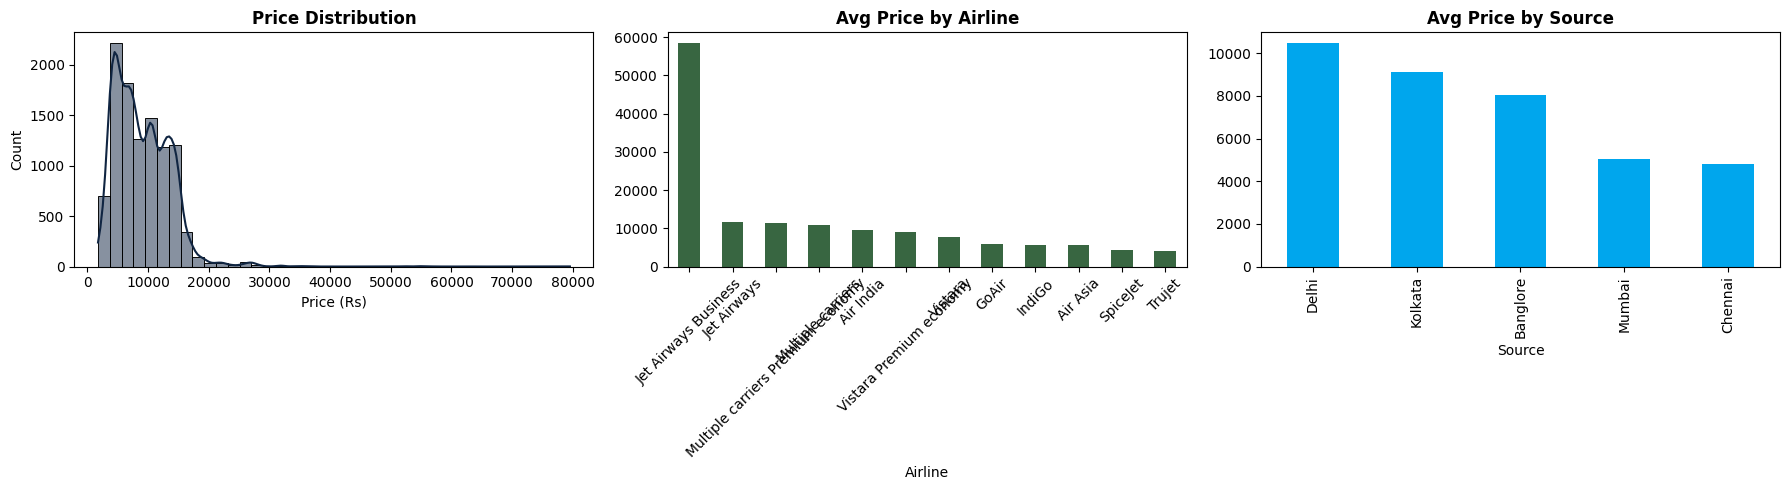

In [120]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Price distribution
sns.histplot(df['Price'], bins=40, kde=True, color='#102542', ax=axes[0])
axes[0].set_title('Price Distribution', fontweight='bold')
axes[0].set_xlabel('Price (Rs)')

# Average price by airline
avg_by_airline = df.groupby('Airline')['Price'].mean().sort_values(ascending=False)
avg_by_airline.plot(kind='bar', color='#386641', ax=axes[1])
axes[1].set_title('Avg Price by Airline', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

# Average price by source city
avg_by_source = df.groupby('Source')['Price'].mean().sort_values(ascending=False)
avg_by_source.plot(kind='bar', color='#00a6ed', ax=axes[2])
axes[2].set_title('Avg Price by Source', fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\tiwar\AppData\Local\Temp\ipykernel_13544\2228005113.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Total_Stops', y='Price', palette='Set2', ax=axes[0])


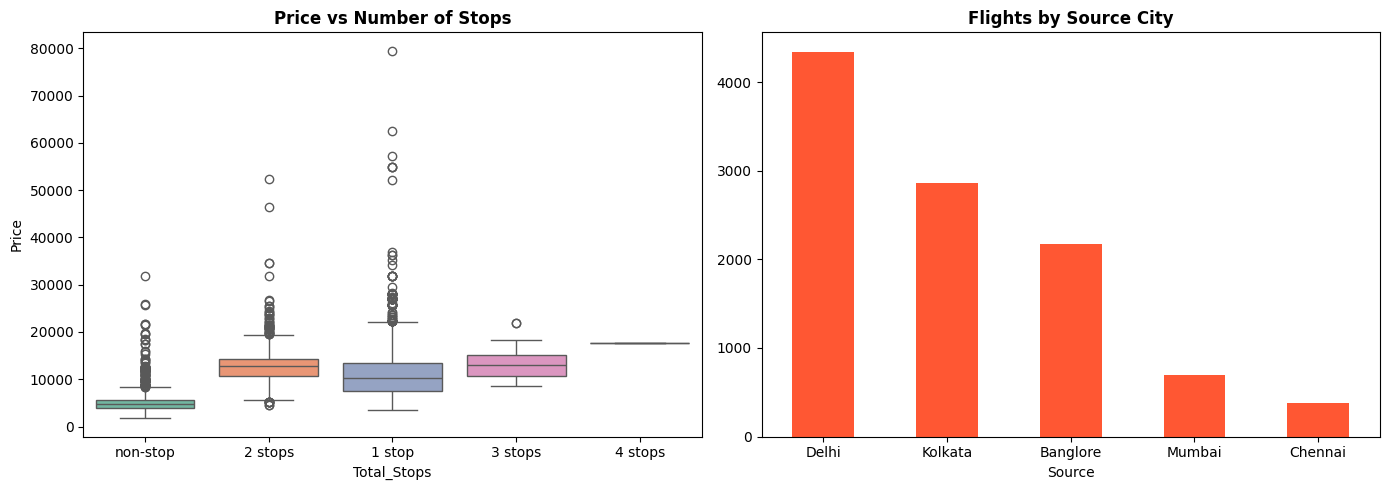

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Price vs Stops
sns.boxplot(data=df, x='Total_Stops', y='Price', palette='Set2', ax=axes[0])
axes[0].set_title('Price vs Number of Stops', fontweight='bold')

# Flights per source city
df['Source'].value_counts().plot(kind='bar', color='#FF5733', ax=axes[1])
axes[1].set_title('Flights by Source City', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## Step 7 — Train-Test Split

In [122]:
features = [
    'Airline_Code', 'Source_Code', 'Destination_Code',
    'Journey_Day', 'Journey_Month', 'Journey_Day_of_Week', 'Is_Weekend',
    'Dep_Hour', 'Dep_Min', 'Dep_Time_Of_Day',
    'Arr_Hour', 'Arr_Min', 'Arr_Time_Of_Day',
    'Duration_Minutes', 'Total_Stops_Code', 'Additional_Info_Code'
]

X = df[features]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


total_rows = len(df)
print("Total Rows :", total_rows)
print("Training Rows :", X_train.shape[0])
print("Testing Rows :", X_test.shape[0])

Total Rows : 10463
Training Rows : 8370
Testing Rows : 2093


## Step 8 — Train & Compare Models

In [123]:
def train_eval(model, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    r2   = r2_score(y_test, pred)
    mae  = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print("Model :", name)
    print("R2 Score :", r2)
    print("MAE :", mae)
    print("RMSE :", rmse)
    print("-----------------------------------")
    return model, r2

lr,  r2_lr  = train_eval(LinearRegression(), 'Linear Regression (Baseline)')
rf,  r2_rf  = train_eval(RandomForestRegressor(n_estimators=200, max_depth=16, random_state=42, n_jobs=-1), 'Random Forest')
xgb, r2_xgb = train_eval(XGBRegressor(n_estimators=300, max_depth=8, learning_rate=0.08, random_state=42, n_jobs=-1), 'XGBoost')

Model : Linear Regression (Baseline)
R2 Score : 0.4586223047885629
MAE : 2405.4284363229804
RMSE : 3360.9045972889253
-----------------------------------
Model : Random Forest
R2 Score : 0.8946386171787312
MAE : 663.4150507151486
RMSE : 1482.6776338338684
-----------------------------------
Model : XGBoost
R2 Score : 0.8969061970710754
MAE : 681.44921875
RMSE : 1466.6356909607784
-----------------------------------


## Step 9 — Model Comparison & Feature Importance

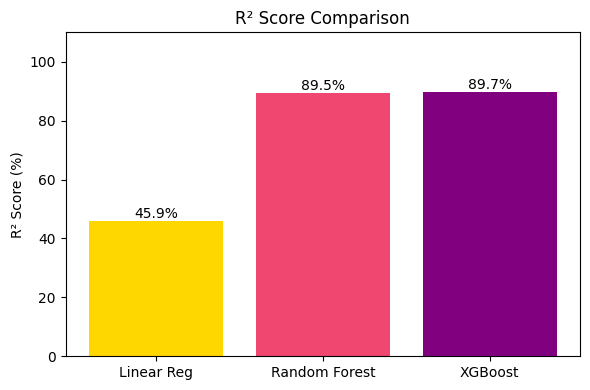

Best Model : XGBoost


In [124]:
import matplotlib.pyplot as plt

# R2 Scores in Percentage
models = ['Linear Reg', 'Random Forest', 'XGBoost']
scores = [r2_lr * 100, r2_rf * 100, r2_xgb * 100]

# Create Graph
fig, ax = plt.subplots(figsize=(6, 4))

# Bar Chart
bars = ax.bar(
    models,
    scores,
    color=['#fed700', '#ef476f', '#800080']
)

# Show Percentage on Top of Bars
ax.bar_label(bars, fmt='%.1f%%')

# Graph Labels
ax.set_title("R² Score Comparison")
ax.set_ylabel("R² Score (%)")
ax.set_ylim(0, 110)

# Display Graph
plt.tight_layout()
plt.show()


# Select Best Model
models = {
    "Linear Regression": r2_lr,
    "Random Forest": r2_rf,
    "XGBoost": r2_xgb
}
best_model = max(models, key=models.get)
print("Best Model :", best_model)

## Step 10 — Save Model

In [125]:
# Save the trained XGBoost model
xgb.get_booster().save_model("best_model.json")
print('Model saved to best_model.json')
print(f'Final R2: {r2_xgb*100:.2f}%')

Model saved to best_model.json
Final R2: 89.69%


## Step 11 — Prediction Simulation

This cell loads the SAVED model from disk — same file the website uses — so predictions here will match the website exactly.

In [126]:
# Load the saved model 
saved_model = XGBRegressor()
saved_model.load_model('best_model.json')

# Reload mappings from file too
with open('mappings.json') as f:
    mappings = json.load(f)

# Standard airlines only (no premium/business — same list as backend)
STANDARD_AIRLINES = [
    'Air Asia', 'Air India', 'GoAir', 'IndiGo',
    'Jet Airways', 'Multiple carriers', 'SpiceJet', 'Trujet', 'Vistara'
]

def predict_all_airlines(source_city, dest_city, day, month, year, dep_h, arr_h):
    src = mappings['Source'][source_city]
    dst = mappings['Destination'][dest_city]

    dt      = pd.to_datetime(f'{year}-{month}-{day}')
    dow     = dt.dayofweek
    weekend = 1 if dow >= 5 else 0

    dep_tod  = time_of_day(dep_h)
    arr_tod  = time_of_day(arr_h)
    duration = (arr_h - dep_h) * 60
    if duration < 0: duration += 1440
    stops    = 0 if duration <= 180 else 1
    no_info  = mappings['Additional_Info']['No info']

    results = []
    for airline in STANDARD_AIRLINES:
        if airline not in mappings['Airline']:
            continue
        row = pd.DataFrame([[
            mappings['Airline'][airline], src, dst,
            day, month, dow, weekend,
            dep_h, 0, dep_tod,
            arr_h, 0, arr_tod,
            duration, stops, no_info
        ]], columns=features)
        price = float(saved_model.predict(row)[0])
        results.append({'airline': airline, 'price': round(price)})

    results.sort(key=lambda x: x['price'])
    return results

# dict_keys(['Banglore', 'Chennai', 'Delhi', 'Kolkata', 'Mumbai'])
# dict_keys(['Banglore', 'Cochin', 'Delhi', 'Hyderabad', 'Kolkata'])

# --- Run ---
preds = predict_all_airlines('Delhi', 'Hyderabad', 16, 10, 2027, 17, 20)

print("Predictions --> ")
print()
print("Source      : Delhi")
print("Destination : Hyderabad")
print("Date        : 16-10-2027")
print("Departure   : 17:00")
print("---------------------------")

for p in preds:
    print(f'{p["airline"]} - Rs {p["price"]:,}')

Predictions --> 

Source      : Delhi
Destination : Hyderabad
Date        : 16-10-2027
Departure   : 17:00
---------------------------
IndiGo - Rs 5,276
GoAir - Rs 5,291
Air Asia - Rs 5,415
Air India - Rs 5,935
SpiceJet - Rs 8,591
Multiple carriers - Rs 8,772
Trujet - Rs 9,092
Vistara - Rs 9,788
Jet Airways - Rs 11,157


## Conclusion

The Flight Price Prediction model successfully estimates ticket prices based on various flight-related features. The trained XGBoost model is capable of providing airline-wise price predictions and can be integrated into a web application for real-time flight price recommendations.